In [10]:
import sys
from pathlib import Path
import time
import numpy as np

root = Path.cwd()
candidates = [root, root.parent, root.parent.parent]
for base in candidates:
    if (base / "efgp_eigenpro_py").exists():
        sys.path.insert(0, str(base))
        break
else:
    raise RuntimeError("cannot find efgp_eigenpro_py from current path")

from efgp_eigenpro_py.efgp_solver import EFGPSolver, PrecomputeState
from efgp_eigenpro_py.discretization import choose_grid_params, basis_weights
from efgp_eigenpro_py.nufft_ops import nufft1d1, nufft2d1, nufft3d1
from efgp_eigenpro_py.kernels import make_squared_exponential, make_matern
from efgp_eigenpro_py.eigenspace import estimate_top_eigenspace
from efgp_eigenpro_py.eigenpro_precond import build_preconditioner
from efgp_eigenpro_py import benchmark as bm

np.set_printoptions(precision=3, suppress=True)

have_plot = False
plt = None


def enable_plotting():
    global have_plot, plt
    try:
        import importlib
        plt = importlib.import_module("matplotlib.pyplot")
        have_plot = True
        print("matplotlib enabled")
    except BaseException as exc:
        have_plot = False
        plt = None
        print("matplotlib not usable, skip plots:", exc)

RUN_STAGE_A = False
RUN_STAGE_B = False
RUN_STAGE_C = False
RUN_STAGE_D = False
RUN_RESIDUAL_DEMO = False

RUN_EXPERIMENT_1 = True
RUN_EXPERIMENT_2 = True
RUN_EXPERIMENT_3 = True

INCLUDE_MATERN12 = False
RUN_RICHARDSON_A = False

MAX_DENSE_M = 5000
MAX_KRR_N = 1200

DEFAULT_TOP_Q = 10


In [11]:
def true_func_1d_f1(x):
    x = np.asarray(x).reshape(-1)
    return np.sin(2 * np.pi * x) + 0.3 * np.cos(6 * np.pi * x)


def true_func_1d_f2(x):
    x = np.asarray(x).reshape(-1)
    return np.sin(2 * np.pi * x) + 0.21 * (x > 0.5)


def true_func_2d(x):
    x = np.asarray(x)
    return (
        np.sin(2 * np.pi * x[:, 0])
        + 0.5 * np.cos(2 * np.pi * x[:, 1])
        + 0.2 * np.sin(2 * np.pi * (x[:, 0] + x[:, 1]))
    )


def true_func_3d(x):
    x = np.asarray(x)
    return (
        np.sin(2 * np.pi * x[:, 0])
        + 0.3 * np.cos(2 * np.pi * x[:, 1])
        + 0.2 * np.sin(2 * np.pi * x[:, 2])
    )


def make_dataset(dim, n, func, noise=0.0, seed=0):
    x, y = bm.make_dataset(dim, n, func, noise=noise, seed=seed)
    f = func(x)
    return x, y, f


def make_test_set(dim, n, func, seed=0):
    return bm.make_test_set(dim, n, func, seed=seed)


In [12]:
def dense_multi_index(m, dim):
    grid = [np.arange(-m, m + 1)] * dim
    mesh = np.meshgrid(*grid, indexing="ij")
    return np.stack([g.reshape(-1) for g in mesh], axis=1)


def build_dense_phi(solver, x, state):
    return bm.build_dense_phi(solver, x, state)


def build_dense_A_rhs(solver, x, y, state):
    return bm.build_dense_A_rhs(solver, x, y, state)


def build_dense_kernel_matrix(kernel, x):
    return bm.kernel_matrix_dense(x, kernel)


def dense_krr_predict(kernel, x_train, y_train, x_eval, reg_lambda):
    K = bm.kernel_matrix_dense(x_train, kernel)
    alpha = np.linalg.solve(K + reg_lambda * np.eye(K.shape[0]), y_train)
    return bm.kernel_predict_block(x_train, alpha, x_eval, kernel)


def compute_rmse(yhat, ytrue):
    return bm.compute_rmse(yhat, ytrue)


In [13]:
def filter_row(row, keys):
    return {k: row.get(k) for k in keys}


def plot_topq_tradeoff(rows, title):
    if not rows:
        return
    if not have_plot:
        print("matplotlib not enabled, skip top_q plot")
        return
    top_q = np.array([r["top_q"] for r in rows], dtype=float)
    solve_plain = np.array([r["solve_time_plain"] for r in rows], dtype=float)
    solve_prec = np.array([r["solve_time_prec"] for r in rows], dtype=float)
    total_plain = np.array([r["total_time_plain"] for r in rows], dtype=float)
    total_prec = np.array([r["total_time_prec"] for r in rows], dtype=float)
    plain_it = np.array([r["plain_it"] for r in rows], dtype=float)
    prec_it = np.array([r["prec_it"] for r in rows], dtype=float)

    plt.figure(figsize=(6, 4))
    plt.plot(top_q, solve_plain, marker="o", label="solve_plain")
    plt.plot(top_q, solve_prec, marker="o", label="solve_prec")
    plt.plot(top_q, total_plain, marker="o", label="total_plain")
    plt.plot(top_q, total_prec, marker="o", label="total_prec")
    plt.xlabel("top_q")
    plt.ylabel("time")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(top_q, plain_it, marker="o", label="plain_it")
    plt.plot(top_q, prec_it, marker="o", label="prec_it")
    plt.xlabel("top_q")
    plt.ylabel("iterations")
    plt.title(title + " (iterations)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [14]:
def print_metrics_table(rows, title):
    if not rows:
        return
    keys = list(rows[0].keys())
    widths = {k: len(k) for k in keys}
    for row in rows:
        for k in keys:
            widths[k] = max(widths[k], len(str(row.get(k, ""))))
    print(title)
    header = " | ".join(k.ljust(widths[k]) for k in keys)
    sep = "-+-".join("-" * widths[k] for k in keys)
    print(header)
    print(sep)
    for row in rows:
        line = " | ".join(str(row.get(k, "")).ljust(widths[k]) for k in keys)
        print(line)


def build_precond_from_state(solver, state, top_q):
    precond, eigpairs, mu, t_eig, t_precond, top_q_used = bm.build_precond_from_state(solver, state, top_q)
    precond_apply = None if precond is None else precond.apply
    return precond_apply, eigpairs, mu, (t_eig, t_precond), top_q_used


def pcg_history(matvec, b, tol, maxiter, precond=None):
    x, it, relres, hist = bm.pcg_solve(matvec, b, tol=tol, maxiter=maxiter, precond=precond, store_history=True)
    return x, hist, it


def richardson_history(matvec, b, x0, eta, maxiter, precond=None):
    x, it, relres, hist = bm.richardson_solve(matvec, b, eta=eta, tol=1e-12, maxiter=maxiter, precond=precond, store_history=True)
    return x, hist


def spectral_metrics(A_dense, eigpairs=None, mu=None, top_q=None):
    return bm.spectral_metrics_dense(A_dense, eigpairs, top_q)


def eigenspace_estimation_metrics(A_dense, solver, state, top_q):
    return bm.eigenspace_estimation_metrics(A_dense, solver, state, top_q)


In [15]:
def precompute_with_timing(solver, x, y):
    return bm.precompute_with_timing(solver, x, y)


In [16]:
def kernel_specs(dim):
    specs = []
    if dim == 1:
        specs.append(("se", make_squared_exponential(lengthscale=0.2, dim=1, variance=1.0)))
        specs.append(("matern32", make_matern(lengthscale=0.2, nu=1.5, dim=1, variance=1.0)))
        if INCLUDE_MATERN12:
            specs.append(("matern12", make_matern(lengthscale=0.2, nu=0.5, dim=1, variance=1.0)))
    elif dim == 2:
        specs.append(("se", make_squared_exponential(lengthscale=0.3, dim=2, variance=1.0)))
        specs.append(("matern32", make_matern(lengthscale=0.3, nu=1.5, dim=2, variance=1.0)))
        if INCLUDE_MATERN12:
            specs.append(("matern12", make_matern(lengthscale=0.3, nu=0.5, dim=2, variance=1.0)))
    else:
        specs.append(("se", make_squared_exponential(lengthscale=0.4, dim=3, variance=1.0)))
        specs.append(("matern32", make_matern(lengthscale=0.4, nu=1.5, dim=3, variance=1.0)))
        if INCLUDE_MATERN12:
            specs.append(("matern12", make_matern(lengthscale=0.4, nu=0.5, dim=3, variance=1.0)))
    return specs


def run_stage_a():
    n_lists = {1: [50, 100, 300, 1000], 2: [50, 100, 300, 1000], 3: [30, 50, 100]}
    funcs_1d = [("f1", true_func_1d_f1), ("f2", true_func_1d_f2)]
    funcs_2d = [("f", true_func_2d)]
    funcs_3d = [("f", true_func_3d)]

    for dim in [1, 2, 3]:
        print("=== Stage A: dim=", dim, "===")
        if dim == 1:
            funcs = funcs_1d
        elif dim == 2:
            funcs = funcs_2d
        else:
            funcs = funcs_3d

        for fname, func in funcs:
            for kname, kernel in kernel_specs(dim):
                for n in n_lists[dim]:
                    print("case=", fname, "kernel=", kname, "n=", n)
                    x_train, y_train, _ = make_dataset(dim, n, func, noise=0.0, seed=0)
                    x_test, y_test = make_test_set(dim, max(60, n // 2), func, seed=1)

                    eps = 1e-4 if dim == 1 else (2e-3 if dim == 2 else 5e-3)
                    solver = EFGPSolver(kernel, reg_lambda=1e-3, eps=eps, nufft_tol=1e-12)

                    t0 = time.perf_counter()
                    state = solver.precompute(x_train, y_train)
                    t1 = time.perf_counter()
                    precompute_time = t1 - t0

                    M = (state.grid.mtot ** dim)
                    dense_ok = M <= MAX_DENSE_M
                    krr_ok = n <= MAX_KRR_N

                    Phi = None
                    A_dense = None
                    rhs_dense = None
                    if dense_ok:
                        Phi, A_dense, rhs_dense = build_dense_A_rhs(solver, x_train, y_train, state)
                    else:
                        print("skip dense weight-space, M=", M)

                    precond, eigpairs, mu, times, top_q_used = build_precond_from_state(solver, state, DEFAULT_TOP_Q)
                    eig_time, precond_time = times

                    matvec = lambda v: solver._apply_A(state, v)

                    t_plain0 = time.perf_counter()
                    beta_plain, h_plain, info_plain = pcg_history(matvec, state.rhs, tol=1e-10, maxiter=500, precond=None)
                    t_plain1 = time.perf_counter()
                    t_prec0 = time.perf_counter()
                    beta_prec, h_prec, info_prec = pcg_history(matvec, state.rhs, tol=1e-10, maxiter=500, precond=precond)
                    t_prec1 = time.perf_counter()

                    if beta_plain is None or beta_prec is None:
                        print("pcg skipped")
                        continue

                    yhat_plain = solver.predict(x_test, beta_plain, state)
                    yhat_prec = solver.predict(x_test, beta_prec, state)

                    train_rmse_plain = compute_rmse(solver.predict(x_train, beta_plain, state), y_train)
                    test_rmse_plain = compute_rmse(yhat_plain, y_test)
                    train_rmse_prec = compute_rmse(solver.predict(x_train, beta_prec, state), y_train)
                    test_rmse_prec = compute_rmse(yhat_prec, y_test)

                    rhs_relerr = None
                    applyA_relerr = None
                    beta_relerr_denseW_plain = None
                    beta_relerr_denseW_prec = None
                    pred_relerr_denseW_plain = None
                    pred_relerr_denseW_prec = None
                    pred_relerr_krr_plain = None
                    pred_relerr_krr_prec = None

                    if dense_ok:
                        rhs_relerr = np.linalg.norm(state.rhs - rhs_dense) / np.linalg.norm(rhs_dense)
                        rng = np.random.default_rng(123)
                        v = rng.normal(size=rhs_dense.size) + 1j * rng.normal(size=rhs_dense.size)
                        Av_fft = solver._apply_A(state, v)
                        Av_dense = A_dense @ v
                        applyA_relerr = np.linalg.norm(Av_fft - Av_dense) / np.linalg.norm(Av_dense)

                        beta_dense = np.linalg.solve(A_dense, rhs_dense)
                        beta_relerr_denseW_plain = np.linalg.norm(beta_plain - beta_dense) / np.linalg.norm(beta_dense)
                        beta_relerr_denseW_prec = np.linalg.norm(beta_prec - beta_dense) / np.linalg.norm(beta_dense)

                        yhat_dense = np.real(build_dense_phi(solver, x_test, state) @ beta_dense)
                        pred_relerr_denseW_plain = np.linalg.norm(yhat_plain - yhat_dense) / np.linalg.norm(yhat_dense)
                        pred_relerr_denseW_prec = np.linalg.norm(yhat_prec - yhat_dense) / np.linalg.norm(yhat_dense)

                        spec = spectral_metrics(A_dense, eigpairs, mu, top_q_used)
                        print("spectral metrics:", spec)

                        est = eigenspace_estimation_metrics(A_dense, solver, state, top_q=top_q_used)
                        print("eigenspace metrics:", est)

                    if krr_ok:
                        yhat_krr = dense_krr_predict(kernel, x_train, y_train, x_test, solver.reg_lambda)
                        pred_relerr_krr_plain = np.linalg.norm(yhat_plain - yhat_krr) / np.linalg.norm(yhat_krr)
                        pred_relerr_krr_prec = np.linalg.norm(yhat_prec - yhat_krr) / np.linalg.norm(yhat_krr)
                    else:
                        print("skip dense KRR, n=", n)

                    rows = [
                        {
                            "method": "plain",
                            "rhs_relerr": rhs_relerr,
                            "applyA_relerr": applyA_relerr,
                            "beta_relerr_denseW": beta_relerr_denseW_plain,
                            "pred_relerr_denseW": pred_relerr_denseW_plain,
                            "pred_relerr_KRR": pred_relerr_krr_plain,
                            "train_RMSE": train_rmse_plain,
                            "test_RMSE": test_rmse_plain,
                            "plain_it": len(h_plain) - 1,
                            "plain_final_relres": float(h_plain[-1]),
                            "solve_time": t_plain1 - t_plain0,
                        },
                        {
                            "method": "precond",
                            "rhs_relerr": rhs_relerr,
                            "applyA_relerr": applyA_relerr,
                            "beta_relerr_denseW": beta_relerr_denseW_prec,
                            "pred_relerr_denseW": pred_relerr_denseW_prec,
                            "pred_relerr_KRR": pred_relerr_krr_prec,
                            "train_RMSE": train_rmse_prec,
                            "test_RMSE": test_rmse_prec,
                            "prec_it": len(h_prec) - 1,
                            "prec_final_relres": float(h_prec[-1]),
                            "solve_time": t_prec1 - t_prec0,
                        },
                    ]
                    print_metrics_table(rows, "Stage A metrics")

                    print("precompute_time=", precompute_time, "eigenspace_time=", eig_time, "precond_time=", precond_time)
                    print("residual_history_plain=", h_plain.tolist())
                    print("residual_history_prec=", h_prec.tolist())

                    if RUN_RICHARDSON_A and dense_ok:
                        eta_plain = 0.9 / np.linalg.norm(A_dense, 2)
                        x0 = np.zeros_like(state.rhs)
                        beta_r, h_r = richardson_history(matvec, state.rhs, x0, eta_plain, maxiter=500, precond=None)
                        eta_prec = 0.9 / float(mu) if mu is not None else eta_plain
                        beta_rp, h_rp = richardson_history(matvec, state.rhs, x0, eta_prec, maxiter=500, precond=precond)
                        print("richardson_plain_final_relres=", float(h_r[-1]))
                        print("richardson_prec_final_relres=", float(h_rp[-1]))

                    print("---")

def run_stage_b():
    n_lists = {1: [1000, 3000, 10000, 30000, 100000, 300000], 2: [1000, 3000, 10000, 30000, 100000]}
    for dim in [1, 2]:
        print("=== Stage B: dim=", dim, "===")
        func = true_func_1d_f1 if dim == 1 else true_func_2d
        for kname, kernel in kernel_specs(dim):
            summary_rows = []
            for n in n_lists[dim]:
                print("kernel=", kname, "n=", n)
                x_train, y_train, _ = make_dataset(dim, n, func, noise=0.0, seed=0)
                x_test, y_test = make_test_set(dim, 200, func, seed=1)

                eps = 1e-4 if dim == 1 else 2e-3
                solver = EFGPSolver(kernel, reg_lambda=1e-3, eps=eps, nufft_tol=1e-12)

                state, pre_times = precompute_with_timing(solver, x_train, y_train)

                precond, _, _, times, _ = build_precond_from_state(solver, state, DEFAULT_TOP_Q)
                eig_time, precond_time = times

                matvec = lambda v: solver._apply_A(state, v)
                t_plain0 = time.perf_counter()
                beta_plain, h_plain, info_plain = pcg_history(matvec, state.rhs, tol=1e-8, maxiter=500, precond=None)
                t_plain1 = time.perf_counter()
                t_prec0 = time.perf_counter()
                beta_prec, h_prec, info_prec = pcg_history(matvec, state.rhs, tol=1e-8, maxiter=500, precond=precond)
                t_prec1 = time.perf_counter()

                if beta_plain is None or beta_prec is None:
                    print("pcg skipped")
                    continue

                t_pred0 = time.perf_counter()
                yhat_plain = solver.predict(x_test, beta_plain, state)
                t_pred1 = time.perf_counter()
                t_pred2 = time.perf_counter()
                yhat_prec = solver.predict(x_test, beta_prec, state)
                t_pred3 = time.perf_counter()

                train_rmse_plain = compute_rmse(solver.predict(x_train, beta_plain, state), y_train)
                test_rmse_plain = compute_rmse(yhat_plain, y_test)
                train_rmse_prec = compute_rmse(solver.predict(x_train, beta_prec, state), y_train)
                test_rmse_prec = compute_rmse(yhat_prec, y_test)

                rows = [
                    {
                        "method": "plain",
                        "plain_it": len(h_plain) - 1,
                        "plain_final_relres": float(h_plain[-1]),
                        "solve_time": t_plain1 - t_plain0,
                        "predict_time": t_pred1 - t_pred0,
                        "train_RMSE": train_rmse_plain,
                        "test_RMSE": test_rmse_plain,
                    },
                    {
                        "method": "precond",
                        "prec_it": len(h_prec) - 1,
                        "prec_final_relres": float(h_prec[-1]),
                        "solve_time": t_prec1 - t_prec0,
                        "predict_time": t_pred3 - t_pred2,
                        "train_RMSE": train_rmse_prec,
                        "test_RMSE": test_rmse_prec,
                    },
                ]
                print_metrics_table(rows, "Stage B metrics")

                total_plain = pre_times["time_precompute_total"] + (t_plain1 - t_plain0)
                total_prec = pre_times["time_precompute_total"] + eig_time + precond_time + (t_prec1 - t_prec0)
                print("precompute_time=", pre_times["time_precompute_total"], "eigenspace_time=", eig_time, "precond_time=", precond_time)
                print("total_plain=", total_plain, "total_prec=", total_prec)
                print("residual_history_plain=", h_plain.tolist())
                print("residual_history_prec=", h_prec.tolist())

                summary_rows.append(
                    {
                        "N": n,
                        "total_plain": total_plain,
                        "total_prec": total_prec,
                        "solve_plain": t_plain1 - t_plain0,
                        "solve_prec": t_prec1 - t_prec0,
                        "eigenspace_time": eig_time,
                    }
                )

                print("---")

        print_metrics_table(summary_rows, f"Stage B cost summary dim={dim} kernel={kname}")
        plot_total_cost_summary(summary_rows, f"Stage B cost summary dim={dim} kernel={kname}")


def plot_total_cost_summary(rows, title):
    if not rows:
        return
    if not have_plot:
        print("matplotlib not enabled, skip cost plot")
        return
    Ns = np.array([r["N"] for r in rows], dtype=float)
    total_plain = np.array([r["total_plain"] for r in rows], dtype=float)
    total_prec = np.array([r["total_prec"] for r in rows], dtype=float)
    solve_plain = np.array([r["solve_plain"] for r in rows], dtype=float)
    solve_prec = np.array([r["solve_prec"] for r in rows], dtype=float)
    eig_time = np.array([r["eigenspace_time"] for r in rows], dtype=float)

    plt.figure(figsize=(6, 4))
    plt.plot(Ns, total_plain, label="total_plain")
    plt.plot(Ns, total_prec, label="total_prec")
    plt.plot(Ns, solve_plain, label="solve_plain")
    plt.plot(Ns, solve_prec, label="solve_prec")
    plt.plot(Ns, eig_time, label="eigenspace_time")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("N")
    plt.ylabel("time")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_residual_demo():
    cases = [
        {"dim": 1, "n": 300, "lengthscale": 0.2, "eps": 1e-4, "top_q": DEFAULT_TOP_Q},
        {"dim": 2, "n": 200, "lengthscale": 0.3, "eps": 2e-3, "top_q": DEFAULT_TOP_Q},
    ]

    for case in cases:
        dim = case["dim"]
        n = case["n"]
        lengthscale = case["lengthscale"]
        eps = case["eps"]
        top_q = case["top_q"]
        func = true_func_1d_f1 if dim == 1 else true_func_2d
        print("=== Residual demo dim=", dim, "n=", n, "===")

        x_train, y_train, _ = make_dataset(dim, n, func, noise=0.0, seed=4)
        kernel = make_squared_exponential(lengthscale=lengthscale, dim=dim, variance=1.0)
        solver = EFGPSolver(kernel, reg_lambda=1e-3, eps=eps, nufft_tol=1e-12)

        state = solver.precompute(x_train, y_train)
        precond, eigpairs, mu, _, top_q_used = build_precond_from_state(solver, state, top_q)
        matvec = lambda v: solver._apply_A(state, v)

        M = state.grid.mtot ** dim
        lam_max = None
        if M <= MAX_DENSE_M:
            _, A_dense, _ = build_dense_A_rhs(solver, x_train, y_train, state)
            lam_max = float(np.linalg.norm(A_dense, 2))
        else:
            if eigpairs is not None and eigpairs.values.size > 0:
                lam_max = float(eigpairs.values[0])

        if lam_max is None:
            lam_max = 1.0

        eta_plain = 0.9 / lam_max
        eta_prec = eta_plain if mu is None else 0.9 / float(mu)

        x0 = np.zeros_like(state.rhs)
        _, hr = richardson_history(matvec, state.rhs, x0, eta_plain, maxiter=200, precond=None)
        _, hrp = richardson_history(matvec, state.rhs, x0, eta_prec, maxiter=200, precond=precond)
        _, hcg, info_cg = pcg_history(matvec, state.rhs, tol=1e-10, maxiter=200, precond=None)
        _, hcgp, info_pcg = pcg_history(matvec, state.rhs, tol=1e-10, maxiter=200, precond=precond)

        print("Richardson it=", len(hr) - 1, "final_relres=", float(hr[-1]))
        print("Precond Richardson it=", len(hrp) - 1, "final_relres=", float(hrp[-1]))
        if hcg is not None:
            print("CG it=", len(hcg) - 1, "final_relres=", float(hcg[-1]), "info=", info_cg)
        if hcgp is not None:
            print("PCG it=", len(hcgp) - 1, "final_relres=", float(hcgp[-1]), "info=", info_pcg)

        if not have_plot:
            print("matplotlib not enabled, skip residual plot")
            continue

        plt.figure(figsize=(6, 4))
        plt.semilogy(hr, label="Richardson")
        plt.semilogy(hrp, label="Precond Richardson")
        if hcg is not None:
            plt.semilogy(np.arange(1, len(hcg) + 1), hcg, label="CG")
        if hcgp is not None:
            plt.semilogy(np.arange(1, len(hcgp) + 1), hcgp, label="PCG")
        plt.xlabel("iteration")
        plt.ylabel("relative residual")
        plt.title(f"dim={dim}, n={n}, top_q={top_q_used}")
        plt.legend()
        plt.tight_layout()
        plt.show()


def run_stage_c():
    print("=== Stage C: parameter sensitivity (2D) ===")
    x, y, _ = make_dataset(2, 60, true_func_2d, noise=0.0, seed=7)
    top_q_list = [0, 2, 5, 10, 20]
    reg_list = [1e-2, 1e-3, 1e-4]
    eps_list = [1e-3, 1e-4, 1e-5]
    l_list = [0.15, 0.25, 0.4]

    for lengthscale in l_list:
        for reg_lambda in reg_list:
            for eps in eps_list:
                print("lengthscale=", lengthscale, "reg_lambda=", reg_lambda, "eps=", eps)
                for top_q in top_q_list:
                    kernel = make_squared_exponential(lengthscale=lengthscale, dim=2, variance=1.0)
                    solver = EFGPSolver(kernel, reg_lambda=reg_lambda, eps=eps, nufft_tol=1e-12)
                    state = solver.precompute(x, y)
                    _, A_dense, rhs_dense = build_dense_A_rhs(solver, x, y, state)
                    matvec = lambda v: solver._apply_A(state, v)

                    precond, _, _, _, top_q_used = build_precond_from_state(solver, state, top_q)

                    xcg, hcg, info_cg = pcg_history(matvec, rhs_dense, tol=1e-8, maxiter=200, precond=None)
                    xcgp, hcgp, info_pcg = pcg_history(matvec, rhs_dense, tol=1e-8, maxiter=200, precond=precond)

                    x_test, y_test = make_test_set(2, 80, true_func_2d, seed=11)
                    train_rmse_plain = compute_rmse(solver.predict(x, xcg, state), y) if xcg is not None else None
                    test_rmse_plain = compute_rmse(solver.predict(x_test, xcg, state), y_test) if xcg is not None else None
                    train_rmse_prec = compute_rmse(solver.predict(x, xcgp, state), y) if xcgp is not None else None
                    test_rmse_prec = compute_rmse(solver.predict(x_test, xcgp, state), y_test) if xcgp is not None else None

                    row = {
                        "top_q": top_q_used,
                        "plain_it": None if hcg is None else len(hcg) - 1,
                        "prec_it": None if hcgp is None else len(hcgp) - 1,
                        "plain_relres": None if hcg is None else float(hcg[-1]),
                        "prec_relres": None if hcgp is None else float(hcgp[-1]),
                        "train_rmse_plain": train_rmse_plain,
                        "test_rmse_plain": test_rmse_plain,
                        "train_rmse_prec": train_rmse_prec,
                        "test_rmse_prec": test_rmse_prec,
                        "info_plain": info_cg,
                        "info_prec": info_pcg,
                    }
                    print(row)


def run_stage_d():
    print("=== Stage D: GPU prep ===")
    cases = [
        {"dim": 1, "n": 10000, "lengthscale": 0.2, "eps": 1e-4},
        {"dim": 2, "n": 10000, "lengthscale": 0.3, "eps": 2e-3},
    ]

    for case in cases:
        dim = case["dim"]
        n = case["n"]
        lengthscale = case["lengthscale"]
        eps = case["eps"]
        func = true_func_1d_f1 if dim == 1 else true_func_2d
        kernel = make_squared_exponential(lengthscale=lengthscale, dim=dim, variance=1.0)
        solver = EFGPSolver(kernel, reg_lambda=1e-3, eps=eps, nufft_tol=1e-12)
        x_train, y_train, _ = make_dataset(dim, n, func, noise=0.0, seed=3)

        state, pre_times = precompute_with_timing(solver, x_train, y_train)
        M = (state.grid.mtot ** dim)
        vector_bytes = 16 * M

        precond, _, _, times, _ = build_precond_from_state(solver, state, DEFAULT_TOP_Q)
        eig_time, precond_time = times

        matvec = lambda v: solver._apply_A(state, v)
        t_plain0 = time.perf_counter()
        beta_plain, h_plain, info_plain = pcg_history(matvec, state.rhs, tol=1e-8, maxiter=300, precond=None)
        t_plain1 = time.perf_counter()
        t_prec0 = time.perf_counter()
        beta_prec, h_prec, info_prec = pcg_history(matvec, state.rhs, tol=1e-8, maxiter=300, precond=precond)
        t_prec1 = time.perf_counter()

        x_test, y_test = make_test_set(dim, 200, func, seed=4)
        t_pred0 = time.perf_counter()
        _ = solver.predict(x_test, beta_plain, state)
        t_pred1 = time.perf_counter()

        rows = [
            {"metric": "time_nufft_v", "value": pre_times["time_nufft_v"]},
            {"metric": "time_fft_embed", "value": pre_times["time_fft_embed"]},
            {"metric": "time_nufft_rhs", "value": pre_times["time_nufft_rhs"]},
            {"metric": "precompute_time", "value": pre_times["time_precompute_total"]},
            {"metric": "eigenspace_time", "value": eig_time},
            {"metric": "precond_time", "value": precond_time},
            {"metric": "solve_time_plain", "value": t_plain1 - t_plain0},
            {"metric": "solve_time_prec", "value": t_prec1 - t_prec0},
            {"metric": "predict_time", "value": t_pred1 - t_pred0},
            {"metric": "total_time_plain", "value": pre_times["time_precompute_total"] + (t_plain1 - t_plain0)},
            {"metric": "total_time_prec", "value": pre_times["time_precompute_total"] + eig_time + precond_time + (t_prec1 - t_prec0)},
        ]
        print("case dim=", dim, "n=", n, "M=", M, "vector_bytes=", vector_bytes)
        print_metrics_table(rows, "Stage D timing")
        print("plain_it=", None if h_plain is None else len(h_plain) - 1, "prec_it=", None if h_prec is None else len(h_prec) - 1)
        print("---")


In [17]:
enable_plotting()

if RUN_STAGE_A:
    run_stage_a()

if RUN_STAGE_B:
    run_stage_b()

if RUN_STAGE_C:
    run_stage_c()

if RUN_STAGE_D:
    run_stage_d()

if RUN_RESIDUAL_DEMO:
    run_residual_demo()


matplotlib enabled


In [18]:
def rough_func_1d(x):
    x = np.asarray(x).reshape(-1)
    return np.sin(2 * np.pi * x) + 0.3 * (x > 0.55)


def rough_func_2d(x):
    x = np.asarray(x)
    return np.sin(2 * np.pi * x[:, 0]) + 0.4 * (x[:, 0] + x[:, 1] > 1.0)


def make_clustered_2d(n, seed=0):
    return bm.make_clustered_2d(n, seed=seed)


def run_case_metrics(
    dim,
    kernel_name,
    kernel,
    x_train,
    y_train,
    x_test,
    y_test,
    reg_lambda,
    eps,
    top_q,
    label=None,
    compute_dense=True,
    compute_krr=True,
):
    krr_pred = None
    krr_ok = compute_krr and (x_train.shape[0] <= MAX_KRR_N)
    if krr_ok:
        krr_pred = dense_krr_predict(kernel, x_train, y_train, x_test, reg_lambda)

    rows = bm.run_efgp_case(
        task_id=label or "case",
        dim=dim,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        kernel=kernel,
        reg_lambda=reg_lambda,
        eps=eps,
        nufft_tol=1e-12,
        top_q=top_q,
        tol=1e-10,
        maxiter=500,
        solver_type="pcg",
        eta=None,
        compute_dense=compute_dense,
        dense_max_m=MAX_DENSE_M,
        dense_max_n=MAX_KRR_N,
        krr_pred=krr_pred,
        store_history=True,
    )

    if not rows:
        print("pcg skipped")
        return None

    plain = next(r for r in rows if r["method"] == "efgp_plain_pcg")
    prec = next(r for r in rows if r["method"] == "efgp_prec_pcg")

    row = {
        "label": label,
        "dim": dim,
        "N": plain.get("N"),
        "kernel": kernel_name,
        "nu": getattr(kernel, "nu", None),
        "lengthscale": kernel.lengthscale,
        "reg_lambda": reg_lambda,
        "eps": eps,
        "top_q": plain.get("top_q"),
        "M": plain.get("M"),
        "cond_A": plain.get("cond_A"),
        "cond_PA": plain.get("cond_PA"),
        "rhs_relerr": plain.get("rhs_relerr"),
        "applyA_relerr": plain.get("applyA_relerr"),
        "beta_relerr_denseW_plain": plain.get("beta_relerr_denseW"),
        "beta_relerr_denseW_prec": prec.get("beta_relerr_denseW"),
        "pred_relerr_denseW_plain": plain.get("pred_relerr_denseW"),
        "pred_relerr_denseW_prec": prec.get("pred_relerr_denseW"),
        "pred_relerr_KRR_plain": plain.get("pred_relerr_KRR"),
        "pred_relerr_KRR_prec": prec.get("pred_relerr_KRR"),
        "train_RMSE_plain": plain.get("train_RMSE"),
        "test_RMSE_plain": plain.get("test_RMSE"),
        "train_RMSE_prec": prec.get("train_RMSE"),
        "test_RMSE_prec": prec.get("test_RMSE"),
        "plain_it": plain.get("plain_it"),
        "prec_it": prec.get("prec_it"),
        "plain_final_relres": plain.get("plain_final_relres"),
        "prec_final_relres": prec.get("prec_final_relres"),
        "precompute_time": plain.get("time_precompute_total"),
        "eigenspace_time": plain.get("time_eigenspace"),
        "precond_time": plain.get("time_precond_build"),
        "solve_time_plain": plain.get("time_solve_plain"),
        "solve_time_prec": prec.get("time_solve_prec"),
        "total_time_plain": plain.get("time_total_plain"),
        "total_time_prec": prec.get("time_total_prec"),
        "eigval_relerr": plain.get("eigval_relerr"),
        "proj_err_fro": plain.get("proj_err_fro"),
        "sin_theta_max": plain.get("sin_theta_max"),
    }
    return row


In [19]:
# Experiment 1: correctness anchor
print("=== Experiment 1: correctness anchor ===")

cases = [
    {"dim": 1, "n": 100, "func": true_func_1d_f1, "lengthscale": 0.2, "eps": 1e-4},
    {"dim": 2, "n": 100, "func": true_func_2d, "lengthscale": 0.2, "eps": 2e-3},
    {"dim": 3, "n": 50, "func": true_func_3d, "lengthscale": 0.4, "eps": 5e-3},
]

keys = [
    "rhs_relerr",
    "applyA_relerr",
    "beta_relerr_denseW_plain",
    "pred_relerr_denseW_plain",
    "beta_relerr_denseW_prec",
    "pred_relerr_denseW_prec",
    "pred_relerr_KRR_plain",
    "pred_relerr_KRR_prec",
    "test_RMSE_plain",
    "test_RMSE_prec",
]

for case in cases:
    dim = case["dim"]
    n = case["n"]
    func = case["func"]
    lengthscale = case["lengthscale"]
    eps = case["eps"]

    x_train, y_train, _ = make_dataset(dim, n, func, noise=0.0, seed=0)
    x_test, y_test = make_test_set(dim, max(60, n // 2), func, seed=1)

    kernel = make_squared_exponential(lengthscale=lengthscale, dim=dim, variance=1.0)
    row = run_case_metrics(
        dim=dim,
        kernel_name="se",
        kernel=kernel,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        reg_lambda=1e-3,
        eps=eps,
        top_q=DEFAULT_TOP_Q,
        label=f"anchor_dim{dim}",
    )
    print({"dim": dim, "N": n, "kernel": "se", "eps": eps})
    print(filter_row(row, keys))
    print("---")


=== Experiment 1: correctness anchor ===
{'dim': 1, 'N': 100, 'kernel': 'se', 'eps': 0.0001}
{'rhs_relerr': 1.3818350039735142e-14, 'applyA_relerr': 2.793906943803698e-14, 'beta_relerr_denseW_plain': 4.3395425760138327e-10, 'pred_relerr_denseW_plain': 1.6694794039091418e-12, 'beta_relerr_denseW_prec': 1.4590133966757346e-10, 'pred_relerr_denseW_prec': 4.143107003620057e-13, 'pred_relerr_KRR_plain': 6.515881419601161e-06, 'pred_relerr_KRR_prec': 6.515881437134717e-06, 'test_RMSE_plain': 0.012122089014461178, 'test_RMSE_prec': 0.012122089014326539}
---


{'dim': 2, 'N': 100, 'kernel': 'se', 'eps': 0.002}
{'rhs_relerr': 7.811514473699392e-14, 'applyA_relerr': 6.069047841353781e-14, 'beta_relerr_denseW_plain': 5.9374019260598225e-08, 'pred_relerr_denseW_plain': 1.70396315406571e-09, 'beta_relerr_denseW_prec': 3.3679807183688543e-07, 'pred_relerr_denseW_prec': 9.4684953007504e-09, 'pred_relerr_KRR_plain': 6.29171651337805e-06, 'pred_relerr_KRR_prec': 6.292798957079147e-06, 'test_RMSE_plain': 0.013374143316665293, 'test_RMSE_prec': 0.013374139907440102}
---
{'dim': 3, 'N': 50, 'kernel': 'se', 'eps': 0.005}
{'rhs_relerr': 1.0267247865571233e-13, 'applyA_relerr': 8.292717618551754e-14, 'beta_relerr_denseW_plain': 7.428553782213531e-08, 'pred_relerr_denseW_plain': 1.593055071318209e-08, 'beta_relerr_denseW_prec': 7.6854247524159e-08, 'pred_relerr_denseW_prec': 1.64375472605884e-08, 'pred_relerr_KRR_plain': 9.521848938956865e-06, 'pred_relerr_KRR_prec': 9.52186971565123e-06, 'test_RMSE_plain': 0.1495374563028319, 'test_RMSE_prec': 0.1495374561

=== Experiment 2: main benchmark (2D uniform, SE) ===
--- spectral probe (cond A / cond PA) ---
{'N': 300, 'M': 289, 'eps': 0.002, 'cond_A': 58294.545635095805, 'cond_PA': 6967.810501193721}
---
{'N': 1000, 'top_q': 0, 'plain_it': 426, 'prec_it': 426, 'plain_final_relres': 8.780185308440644e-11, 'prec_final_relres': 8.780185308440644e-11, 'solve_time_plain': 0.16502680000849068, 'solve_time_prec': 0.17547819996252656, 'total_time_plain': 0.17795409983955324, 'total_time_prec': 0.18840549979358912, 'eigenspace_time': 0.0, 'test_RMSE_plain': 0.0009119655942098011, 'test_RMSE_prec': 0.0009119655942098011}
{'N': 1000, 'top_q': 5, 'plain_it': 420, 'prec_it': 303, 'plain_final_relres': 6.006900321372371e-11, 'prec_final_relres': 6.955369863034628e-11, 'solve_time_plain': 0.16353829996660352, 'solve_time_prec': 0.13599970005452633, 'total_time_plain': 0.17049099993892014, 'total_time_prec': 0.15010449988767505, 'eigenspace_time': 0.007106199860572815, 'test_RMSE_plain': 0.0009119632367090044,

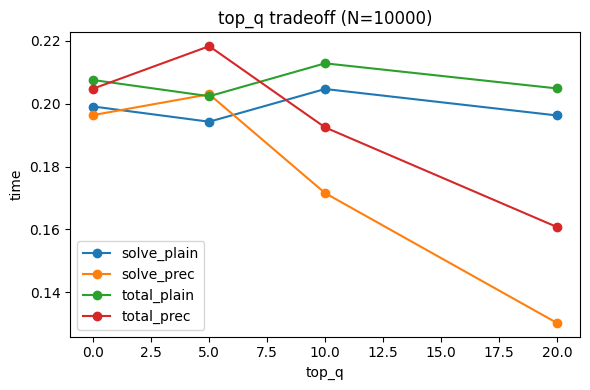

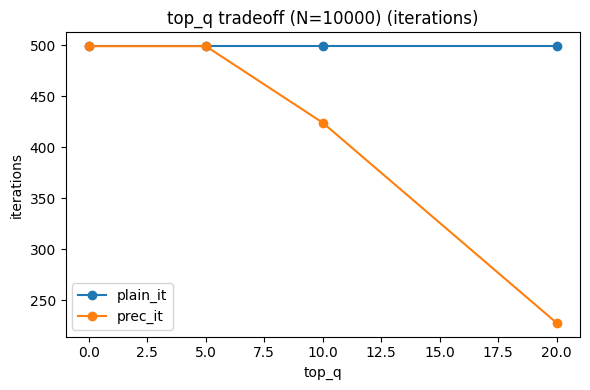

N scaling summary (top_q=10)
N      | total_plain        | total_prec          | solve_plain         | solve_prec          | eigenspace_time     
-------+--------------------+---------------------+---------------------+---------------------+---------------------
1000   | 0.1677450998686254 | 0.11166539997793734 | 0.16019789990969002 | 0.0894440000411123  | 0.01459840009920299 
10000  | 0.212818400003016  | 0.19245510012842715 | 0.20465720002539456 | 0.17156630009412766 | 0.012680400162935257
100000 | 0.220769900130108  | 0.28378989989869297 | 0.1935511000920087  | 0.244095099857077   | 0.012424000073224306


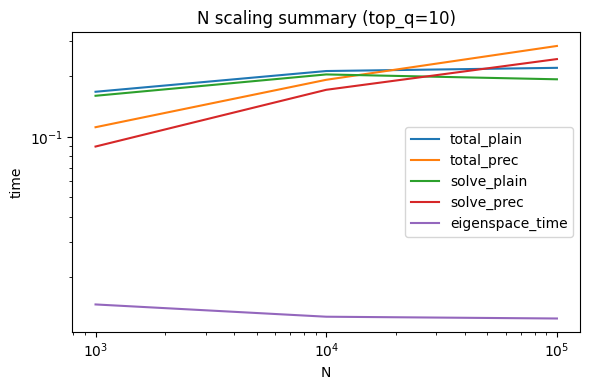

In [20]:
# Experiment 2: main benchmark (2D uniform, SE)
print("=== Experiment 2: main benchmark (2D uniform, SE) ===")

N_list = [1000, 10000, 100000]
top_q_list = [0, 5, 10, 20]
lengthscale = 0.2
reg_lambda = 1e-3
eps = 1e-4

# spectral probe (small eps to keep M manageable)
print("--- spectral probe (cond A / cond PA) ---")
probe_n = 300
probe_eps = 2e-3
x_probe, y_probe, _ = make_dataset(2, probe_n, true_func_2d, noise=0.0, seed=2)
x_probe_test, y_probe_test = make_test_set(2, 80, true_func_2d, seed=3)
probe_kernel = make_squared_exponential(lengthscale=lengthscale, dim=2, variance=1.0)
probe_row = run_case_metrics(
    dim=2,
    kernel_name="se",
    kernel=probe_kernel,
    x_train=x_probe,
    y_train=y_probe,
    x_test=x_probe_test,
    y_test=y_probe_test,
    reg_lambda=reg_lambda,
    eps=probe_eps,
    top_q=DEFAULT_TOP_Q,
    label="spectral_probe",
    compute_krr=False,
)
print(filter_row(probe_row, ["N", "M", "eps", "cond_A", "cond_PA"]))
print("---")

rows_all = []
for n in N_list:
    x_train, y_train, _ = make_dataset(2, n, true_func_2d, noise=0.0, seed=0)
    x_test, y_test = make_test_set(2, 200, true_func_2d, seed=1)

    for top_q in top_q_list:
        kernel = make_squared_exponential(lengthscale=lengthscale, dim=2, variance=1.0)
        row = run_case_metrics(
            dim=2,
            kernel_name="se",
            kernel=kernel,
            x_train=x_train,
            y_train=y_train,
            x_test=x_test,
            y_test=y_test,
            reg_lambda=reg_lambda,
            eps=eps,
            top_q=top_q,
            label="main_benchmark",
            compute_dense=False,
            compute_krr=False,
        )
        rows_all.append(row)
        print(filter_row(row, [
            "N",
            "top_q",
            "plain_it",
            "prec_it",
            "plain_final_relres",
            "prec_final_relres",
            "solve_time_plain",
            "solve_time_prec",
            "total_time_plain",
            "total_time_prec",
            "eigenspace_time",
            "test_RMSE_plain",
            "test_RMSE_prec",
        ]))

# top_q tradeoff at N=10000
rows_topq = [r for r in rows_all if r["N"] == 10000]
print_metrics_table(rows_topq, "top_q tradeoff (N=10000)")
plot_topq_tradeoff(rows_topq, "top_q tradeoff (N=10000)")

# N scaling at top_q=10
rows_n = [
    {
        "N": r["N"],
        "total_plain": r["total_time_plain"],
        "total_prec": r["total_time_prec"],
        "solve_plain": r["solve_time_plain"],
        "solve_prec": r["solve_time_prec"],
        "eigenspace_time": r["eigenspace_time"],
    }
    for r in rows_all if r["top_q"] == 10
]
print_metrics_table(rows_n, "N scaling summary (top_q=10)")
plot_total_cost_summary(rows_n, "N scaling summary (top_q=10)")


In [21]:
# Experiment 3: robustness case (2D clustered, SE)
print("=== Experiment 3: robustness case (2D clustered, SE) ===")

N_list = [3000, 10000]
top_q_list = [0, 10, 20]
lengthscale = 0.2
reg_lambda = 1e-3
eps = 1e-4

for n in N_list:
    x_train = make_clustered_2d(n, seed=5)
    y_train = true_func_2d(x_train)
    x_test, y_test = make_test_set(2, 200, true_func_2d, seed=6)

    for top_q in top_q_list:
        kernel = make_squared_exponential(lengthscale=lengthscale, dim=2, variance=1.0)
        row = run_case_metrics(
            dim=2,
            kernel_name="se",
            kernel=kernel,
            x_train=x_train,
            y_train=y_train,
            x_test=x_test,
            y_test=y_test,
            reg_lambda=reg_lambda,
            eps=eps,
            top_q=top_q,
            label="robust_cluster",
            compute_dense=False,
            compute_krr=False,
        )
        print(filter_row(row, [
            "N",
            "top_q",
            "plain_it",
            "prec_it",
            "solve_time_plain",
            "solve_time_prec",
            "total_time_plain",
            "total_time_prec",
            "test_RMSE_plain",
            "test_RMSE_prec",
        ]))


=== Experiment 3: robustness case (2D clustered, SE) ===
{'N': 3000, 'top_q': 0, 'plain_it': 184, 'prec_it': 184, 'solve_time_plain': 0.07558290008455515, 'solve_time_prec': 0.07287669996730983, 'total_time_plain': 0.08387470012530684, 'total_time_prec': 0.08116850000806153, 'test_RMSE_plain': 0.2768344522868683, 'test_RMSE_prec': 0.2768344522868683}
{'N': 3000, 'top_q': 10, 'plain_it': 179, 'prec_it': 60, 'solve_time_plain': 0.08034060010686517, 'solve_time_prec': 0.03777159983292222, 'total_time_plain': 0.08739010011777282, 'total_time_prec': 0.05378359998576343, 'test_RMSE_plain': 0.2768344526527292, 'test_RMSE_prec': 0.27683445250912003}
{'N': 3000, 'top_q': 20, 'plain_it': 177, 'prec_it': 24, 'solve_time_plain': 0.06999439978972077, 'solve_time_prec': 0.01614609989337623, 'total_time_plain': 0.07779979961924255, 'total_time_prec': 0.05015749973244965, 'test_RMSE_plain': 0.27683445244277893, 'test_RMSE_prec': 0.2768344856791832}
{'N': 10000, 'top_q': 0, 'plain_it': 250, 'prec_it': 

In [22]:
def filter_row(row, keys):
    return {k: row.get(k) for k in keys}


def plot_topq_tradeoff(rows, title):
    if not rows:
        return
    if not have_plot:
        print("matplotlib not enabled, skip top_q plot")
        return
    top_q = np.array([r["top_q"] for r in rows], dtype=float)
    solve_plain = np.array([r["solve_time_plain"] for r in rows], dtype=float)
    solve_prec = np.array([r["solve_time_prec"] for r in rows], dtype=float)
    total_plain = np.array([r["total_time_plain"] for r in rows], dtype=float)
    total_prec = np.array([r["total_time_prec"] for r in rows], dtype=float)
    plain_it = np.array([r["plain_it"] for r in rows], dtype=float)
    prec_it = np.array([r["prec_it"] for r in rows], dtype=float)

    plt.figure(figsize=(6, 4))
    plt.plot(top_q, solve_plain, marker="o", label="solve_plain")
    plt.plot(top_q, solve_prec, marker="o", label="solve_prec")
    plt.plot(top_q, total_plain, marker="o", label="total_plain")
    plt.plot(top_q, total_prec, marker="o", label="total_prec")
    plt.xlabel("top_q")
    plt.ylabel("time")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(top_q, plain_it, marker="o", label="plain_it")
    plt.plot(top_q, prec_it, marker="o", label="prec_it")
    plt.xlabel("top_q")
    plt.ylabel("iterations")
    plt.title(title + " (iterations)")
    plt.legend()
    plt.tight_layout()
    plt.show()
